In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from scipy.stats import ks_2samp, mannwhitneyu, spearmanr
from IPython.display import display
import os

In [61]:
output_folder = "histogram_plots"
os.makedirs(output_folder, exist_ok=True)

stats_results = []

In [62]:
clusters_to_use = [
    "NGC_104","NGC_288","NGC_362","NGC_1851","NGC_1904","NGC_2298","NGC_2808",
    "NGC_3201","NGC_4147","NGC_4590","NGC_5024","NGC_5053","NGC_5139","NGC_5272",
    "NGC_5466","NGC_5634","NGC_5904","NGC_6093","NGC_6121","NGC_6144","NGC_6171",
    "NGC_6205","NGC_6218","NGC_6229","NGC_6254","NGC_6273","NGC_6293","NGC_6304",
    "NGC_6316","NGC_6341","NGC_6380","NGC_6388","NGC_6397","NGC_6401","NGC_6441",
    "NGC_6517","NGC_6522","NGC_6528","NGC_6539","NGC_6540","NGC_6544","NGC_6553",
    "NGC_6558","NGC_6569","NGC_6642","NGC_6656","NGC_6715","NGC_6717","NGC_6723",
    "NGC_6752","NGC_6760","NGC_6809","NGC_6838","NGC_7078","NGC_7089","Pal_1",
    "Pal_10","Pal_5","Pal_6","Rup_106","Ter_10","Ter_12","Ter_2","Ter_4","Ter_5",
    "Ter_9","Ton_2","UKS_1","Djor_2","FSR_1758","HP_1","Liller_1"
]

undetermined_clusters = [
    "NGC_4147","NGC_5634","NGC_6093","NGC_6144","NGC_6401","NGC_6517",
    "NGC_6528","NGC_6539","NGC_6540","NGC_6558","NGC_6717","NGC_6723",
    "Pal_1","Pal_10","Pal_6","Rup_106","Ter_10","Ter_12",
    "Ter_2","Ter_4","UKS_1"
]

p2_certain = ["NGC_5139","NGC_2808","NGC_6205","NGC_7078"]

p2_likely = ["NGC_5139","NGC_2808","NGC_6205","NGC_7078",
            "NGC_1904", "NGC_6273", "NGC_6341", "NGC_6715", "NGC_6752"]

p2_potential = ["NGC_5139","NGC_2808","NGC_6205","NGC_7078",
            "NGC_1904", "NGC_6273", "NGC_6341", "NGC_6715", "NGC_6752",
               "NGC_6254", "NGC_6388", "NGC_7089", "NGC_6293"]

analysis_level = "likely"   # certain=high-likelihood, likely=moderate-likelihood, potential=low-likelihood

In [63]:
hbr_borkova_data = {
    "NGC_104": -0.99, "NGC_288": 0.98, "NGC_362": -0.87, "NGC_1851": -0.234,
    "NGC_1904": -0.89, "NGC_2298": -0.93, "NGC_2808": -0.49, "NGC_3201": 0.08,
    "NGC_4147": 0.55, "NGC_4590": 0.17, "NGC_5024": 0.76, "NGC_5053": 0.52,
    "NGC_5139": 0.89, "NGC_5272": 0.08, "NGC_5466": 0.58, "NGC_5904": 0.31,
    "NGC_6093": 0.93, "NGC_6121": -0.06, "NGC_6144": 1.00, "NGC_6171": -0.73,
    "NGC_6205": 0.97, "NGC_6218": 0.97, "NGC_6229": 0.24, "NGC_6254": 0.98,
    "NGC_6293": 0.90, "NGC_6304": -1.00, "NGC_6316": -1.00, "NGC_6341": 0.91,
    "NGC_6397": 0.98, "NGC_6522": 0.71, "NGC_6528": -1.00, "NGC_6539": -1.00,
    "NGC_6544": 1.00, "NGC_6553": -1.00, "NGC_6656": 0.91, "NGC_6715": 0.87,
    "NGC_6717": 0.98, "NGC_6723": -0.08, "NGC_6752": 1.00, "NGC_6760": -1.00,
    "NGC_6809": 0.87, "NGC_6838": -1.00, "NGC_7078": 0.67, "NGC_7089": 0.96,
    "Pal_1": -1.00, "Pal_10": -1.00, "Pal_5": -0.40, "Pal_6": -1.00,
    "Rup_106": -0.82, "Ter_2": -1.00, "Ter_5": -1.00, "Liller_1": -1.00
}

hbr_dotter_data = {
    "NGC_104": 0.153, "NGC_288": 1.022, "NGC_362": 0.195, "NGC_1851": 0.234,
    "NGC_2298": 0.871, "NGC_2808": 0.966, "NGC_3201": 0.523, "NGC_4147": 0.838,
    "NGC_4590": 0.700, "NGC_5024": 0.851, "NGC_5053": 0.782, "NGC_5272": 0.736,
    "NGC_5466": 0.721, "NGC_5904": 0.874, "NGC_6093": 0.923, "NGC_6121": 0.541,
    "NGC_6144": 0.879, "NGC_6171": 0.204, "NGC_6205": 1.047, "NGC_6218": 0.986,
    "NGC_6254": 1.022, "NGC_6304": 0.105, "NGC_6341": 0.910, "NGC_6388": 0.126,
    "NGC_6397": 0.944, "NGC_6441": 0.110, "NGC_6656": 0.935, "NGC_6717": 0.948,
    "NGC_6723": 0.371, "NGC_6752": 1.082, "NGC_6809": 0.906, "NGC_6838": 0.106,
    "NGC_7078": 0.876, "NGC_7089": 0.951
}

hbr_harris_data = {
    "NGC_104": -0.99, "NGC_288": 0.98, "NGC_362": -0.87, "NGC_1851": -0.36, "NGC_1904": 0.89, "NGC_2298": 0.93, "NGC_2808": -0.49,
    "NGC_3201": 0.08, "NGC_4147": 0.55, "NGC_4590": 0.17, "NGC_5024": 0.81, "NGC_5053": 0.52, "NGC_5139": 0.90, "NGC_5272": 0.08,
    "NGC_5466": 0.58, "NGC_5634": 0.91, "NGC_5904": 0.31, "NGC_6093": 0.93, "NGC_6121": -0.06, "NGC_6144": 1.00, "NGC_6171": -0.73,
    "NGC_6205": 0.97, "NGC_6218": 0.97, "NGC_6229": 0.24, "NGC_6254": 0.98, "NGC_6273": 0.98, "NGC_6293": 0.90, "NGC_6304": -0.93,
    "NGC_6316": -0.91, "NGC_6341": 0.91, "NGC_6380": -1.00, "NGC_6388": -1.00, "NGC_6397": 0.98, "NGC_6401": -0.97, "NGC_6441": -1.00,
    "NGC_6517": 1.00, "NGC_6522": 0.71, "NGC_6528": -1.00, "NGC_6539": -0.86, "NGC_6540": -1.00, "NGC_6544": 1.00, "NGC_6553": -1.00,
    "NGC_6558": 0.80, "NGC_6569": -0.82, "NGC_6642": 0.91, "NGC_6656": 0.91, "NGC_6715": 0.54, "NGC_6717": 0.98, "NGC_6723": -0.08,
    "NGC_6752": 1.00, "NGC_6760": -0.93, "NGC_6809": 0.87, "NGC_6838": -1.00, "NGC_7078": 0.67, "NGC_7089": 0.96, "Pal_1": -1.00,
    "Pal_10": -1.00, "Pal_5": -0.40, "Pal_6": -1.00, "Rup_106": -0.82, "Ter_10": -1.00, "Ter_12": -1.00, "Ter_2": -1.00, "Ter_4": -1.00,
    "Ter_5": -1.00, "Ter_9": -1.00, "Ton_2": -1.00, "UKS_1": -1.00, "Djor_2": -1.00, "FSR_1758": 0.90, "HP_1": 0.75, "Liller_1": -1.00
}

hbr_harris_excluded_clusters = [
    "NGC_6380", "NGC_6401", "NGC_6441", "NGC_6528", "NGC_6539", "NGC_6540",
    "NGC_6553", "NGC_6569", "NGC_6760",
    "Ter_10", "Ter_12", "Ter_2", "Ter_4", "Ter_5", "Ter_9",
    "Ton_2", "UKS_1", "Djor_2", "Liller_1",
    "Pal_10", "Pal_6"
]

In [64]:
combined_file = "C:/Users/sgjdemps/Downloads/combined_table.txt"
orbit_file = "C:/Users/sgjdemps/Downloads/orbits_table.txt"

In [65]:
def numeric_convert(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass
    return df

with open(combined_file) as f:
    lines = f.readlines()

if lines[0].startswith("#"):
    lines[0] = lines[0].replace("#", "", 1)

df_comb = pd.read_csv(
    StringIO("".join(lines)),
    sep=r"\s+",
    engine="python",
    header=None,
    on_bad_lines="skip"
)
df_comb.columns = df_comb.iloc[0]
df_comb = df_comb.iloc[2:].reset_index(drop=True)
df_comb = numeric_convert(df_comb)
df_comb["Cluster"] = df_comb["Cluster"].astype(str).str.strip().str.replace(" ", "_", regex=False)

print(df_comb.head())
print(df_comb.columns)

0    Cluster        RA       DEC  R_Sun  DRSun   R_GC  DRGC  N_RV   N_PM  \
0    NGC_104   6.02379 -72.08131   4.52   0.03   7.52  0.01  7177  27460   
1    NGC_288  13.18850 -26.58261   8.99   0.09  12.21  0.06   549   2637   
2    NGC_362  15.80942 -70.84878   8.83   0.10   9.62  0.06  2342   4286   
3  Whiting_1  30.73750  -3.25278  30.59   1.17  35.15  1.11     3      0   
4   NGC_1261  48.06754 -55.21622  16.40   0.19  18.28  0.17   345   3179   

0      Mass  ...  M_High    MF  Delta_MF  sig0  vesc  etac  etah  A_Rot  \
0  853000.0  ...    0.86 -0.65      0.12  11.9  47.4 -0.40 -0.04   5.00   
1   96200.0  ...    0.82 -0.66      0.11   3.1  10.9 -0.31 -0.10   0.42   
2  252000.0  ...    0.82 -0.76      0.13   8.6  34.0 -0.38 -0.11   0.51   
3    1370.0  ...    0.99 -1.16      0.60   0.3   1.1 -0.16 -0.03    NaN   
4  172000.0  ...    0.83 -0.61      0.13   5.7  21.4 -0.34 -0.11   0.90   

0  Delta_AR  P_Rot  
0      0.32  100.0  
1      0.32   84.3  
2      0.56   53.0  
3       

In [66]:
df_orb = pd.read_csv(
    orbit_file,
    sep=r"\s+",
    engine="python",
    header=None,
    on_bad_lines="skip"
)
df_orb.columns = df_orb.iloc[0]
df_orb = df_orb.iloc[2:].reset_index(drop=True)
df_orb = numeric_convert(df_orb)
df_orb = df_orb.rename(columns={"#Cluster": "Cluster"})
df_orb["Cluster"] = df_orb["Cluster"].astype(str).str.strip().str.replace(" ", "_", regex=False)

print(df_orb.head())
print(df_orb.columns)

0    Cluster         RA        DEC        l       b   Rsun  Delta_R   R_GC  \
0    NGC_104   6.023792 -72.081306  305.895 -44.889   4.52     0.03   7.52   
1    NGC_288  13.188500 -26.582611  151.285 -89.380   8.99     0.09  12.21   
2    NGC_362  15.809416 -70.848778  301.533 -46.247   8.83     0.10   9.62   
3  Whiting_1  30.737499  -3.252778  161.618 -60.636  30.59     1.17  35.15   
4   NGC_1261  48.067543 -55.216225  270.539 -52.124  16.40     0.19  18.28   

0    <RV>   ERV  ...       U Delta_U       V Delta_V      W  Delta_W  R_Per  \
0  -17.45  0.16  ...   77.52    0.17  170.83    0.17  46.02     0.17   5.47   
1  -44.45  0.13  ...    4.20    0.15  -48.34    0.16  50.29     0.13   1.93   
2  223.12  0.28  ...   93.45    0.36  -98.32    0.33 -67.93     0.32   0.73   
3 -130.41  1.79  ... -246.96    6.29   32.88    6.60  -7.97     3.57  35.15   
4   71.34  0.21  ...  -78.82    0.70   57.52    0.57  68.81     0.46   1.65   

0  Delta_R  R_Apo  Delta_R  
0     0.01   7.51     0.00 

In [67]:
df_orb.columns = [
    "Cluster", "RA_orb", "DEC_orb", "l", "b", "Rsun_orb", "Delta_Rsun",
    "R_GC_orb", "RV", "ERV", "mualpha", "Delta_mualpha", "mu_delta",
    "Delta_mu_delta", "corr", "X", "Delta_X", "Y", "Delta_Y", "Z",
    "Delta_Z", "U", "Delta_U", "V_orb", "Delta_V_orb", "W", "Delta_W",
    "R_Per", "Delta_R_Per", "R_Apo", "Delta_R_Apo"
]

df_all = pd.merge(df_comb, df_orb, on="Cluster", how="inner")
df_all = df_all[df_all["Cluster"].isin(clusters_to_use)].copy()

hbr_df = pd.DataFrame({
    "Cluster": sorted(set(list(hbr_borkova_data.keys()) + list(hbr_dotter_data.keys()) + list(hbr_harris_data.keys())))
})
hbr_df["HBR_Borkova"] = hbr_df["Cluster"].map(hbr_borkova_data)
hbr_df["HBR_Dotter"] = hbr_df["Cluster"].map(hbr_dotter_data)
hbr_df["HBR_Harris"] = hbr_df["Cluster"].map(hbr_harris_data)

df_use = df_all.merge(hbr_df, on="Cluster", how="left")
print("Total clusters in final catalogue:", len(df_use))

print(df_use.head())
print(df_use.columns)

Total clusters in final catalogue: 72
    Cluster        RA       DEC  R_Sun  DRSun   R_GC  DRGC  N_RV   N_PM  \
0   NGC_104   6.02379 -72.08131   4.52   0.03   7.52  0.01  7177  27460   
1   NGC_288  13.18850 -26.58261   8.99   0.09  12.21  0.06   549   2637   
2   NGC_362  15.80942 -70.84878   8.83   0.10   9.62  0.06  2342   4286   
3     Pal_1  53.33350  79.58105  11.18   0.32  17.41  0.29     7      0   
4  NGC_1851  78.52816 -40.04655  11.95   0.13  16.69  0.11  8217   4973   

       Mass  ...  Delta_V_orb      W  Delta_W  R_Per  Delta_R_Per  R_Apo  \
0  853000.0  ...         0.17  46.02     0.17   5.47         0.01   7.51   
1   96200.0  ...         0.16  50.29     0.13   1.93         0.10  12.34   
2  252000.0  ...         0.33 -67.93     0.32   0.73         0.06  11.84   
3     926.0  ...         0.99 -24.56     1.41  14.77         0.29  18.98   
4  283000.0  ...         1.19 -83.31     0.97   0.90         0.03  19.90   

   Delta_R_Apo  HBR_Borkova  HBR_Dotter  HBR_Harris  


In [68]:
columns_to_show = [
    "Cluster",
    "Mass", "rc", "rho_c", "lg(Mini)", "sig0", "R_Per",
    "HBR_Borkova", "HBR_Dotter", "HBR_Harris"
]

with pd.option_context("display.max_rows", None):
    display(df_use[columns_to_show])

,Cluster,Mass,rc,rho_c,lg(Mini),sig0,R_Per,HBR_Borkova,HBR_Dotter,HBR_Harris
0,NGC_104,853000.0,0.61,4.72,6.24,11.9,5.47,-0.990,0.153,-0.99
1,NGC_288,96200.0,3.50,1.83,5.60,3.1,1.93,0.980,1.022,0.98
2,NGC_362,252000.0,0.43,4.57,6.05,8.6,0.73,-0.870,0.195,-0.87
3,Pal_1,926.0,0.46,2.03,4.09,0.5,14.77,-1.000,NaN,-1.00
4,NGC_1851,283000.0,0.14,6.32,6.02,10.3,0.90,-0.234,0.234,-0.36
5,NGC_1904,181000.0,0.33,4.56,6.46,6.7,0.30,-0.890,NaN,0.89
6,NGC_2298,49800.0,0.43,3.85,5.78,3.9,0.97,-0.930,0.871,0.93
7,NGC_2808,791000.0,0.74,4.52,6.29,13.8,1.08,-0.490,0.966,-0.49
8,NGC_3201,193000.0,1.66,2.82,5.61,4.5,8.34,0.080,0.523,0.08
9,NGC_4147,45100.0,0.43,3.89,5.47,3.6,1.83,0.550,0.838,0.55


In [69]:
analysis_level_labels = {
    "certain": "High-likelihood",
    "likely": "Moderate-likelihood",
    "potential": "Low-likelihood"
}

if analysis_level == "certain":
    p2_clusters = p2_certain
elif analysis_level == "likely":
    p2_clusters = p2_likely
elif analysis_level == "potential":
    p2_clusters = p2_potential
else:
    raise ValueError("analysis_level must be 'certain', 'likely', or 'potential'")

df_use["P2"] = df_use["Cluster"].isin(p2_clusters)

df_hist = df_use[~df_use["Cluster"].isin(undetermined_clusters)].copy()

df_p2 = df_hist[df_hist["P2"]].copy()
df_nonp2 = df_hist[~df_hist["P2"]].copy()

print("Total clusters in full catalogue:", len(df_use))
print("Clusters used in histograms:", len(df_hist))
print("Excluded as undetermined (<10 stars):", len(undetermined_clusters))
print("")
print("Analysis level:", analysis_level, f"({analysis_level_labels[analysis_level]})" if "analysis_level_labels" in globals() else "")
print("P2 clusters:", len(df_p2))
print("Non-P2 clusters:", len(df_nonp2))

Total clusters in full catalogue: 72
Clusters used in histograms: 51
Excluded as undetermined (<10 stars): 21

Analysis level: likely (Moderate-likelihood)
P2 clusters: 9
Non-P2 clusters: 42


Dotter HBR vs present-day cluster mass
N = 29
Spearman rho = 0.0621
p-value = 0.749 (not significant at alpha = 0.05)
Saved Spearman result to dotter_hbr_mass_spearman_likely.csv
Saved plot to histogram_plots\HBR_Dotter_vs_Mass_Spearman_likely.png


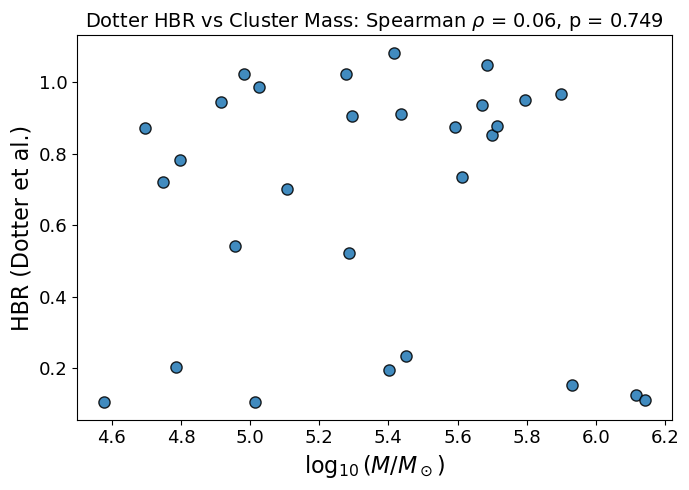

,Cluster,Mass,log10_Mass,HBR_Dotter
69,NGC_6838,37800.0,4.577492,0.106
6,NGC_2298,49800.0,4.697229,0.871
16,NGC_5466,56100.0,4.748963,0.721
23,NGC_6171,61200.0,4.786751,0.204
13,NGC_5053,62800.0,4.797960,0.782
41,NGC_6397,82400.0,4.915927,0.944
21,NGC_6121,90400.0,4.956168,0.541
1,NGC_288,96200.0,4.983175,1.022
30,NGC_6304,103000.0,5.012837,0.105
25,NGC_6218,106000.0,5.025306,0.986


,Comparison,Sample,N,Spearman_rho,p_value,Significant_at_0.05
0,HBR_Dotter vs Mass,df_hist main sample,29,0.062077,0.749047,False


In [70]:
def run_dotter_hbr_mass_spearman(
    df,
    mass_col="Mass",
    hbr_col="HBR_Dotter",
    cluster_col="Cluster",
    alpha=0.05,
    save_plot=True
):
    sub = df[[cluster_col, mass_col, hbr_col]].copy()

    sub[mass_col] = pd.to_numeric(sub[mass_col], errors="coerce")
    sub[hbr_col] = pd.to_numeric(sub[hbr_col], errors="coerce")

    sub = sub.replace([99, 99.99, -99, -99.99, 999, -999], np.nan)
    sub = sub.dropna(subset=[mass_col, hbr_col]).copy()

    sub = sub[sub[mass_col] > 0].copy()
    sub["log10_Mass"] = np.log10(sub[mass_col])

    if len(sub) < 3:
        raise ValueError("Not enough clusters with both Mass and HBR_Dotter to run Spearman test.")

    rho, p_value = spearmanr(sub["log10_Mass"], sub[hbr_col])

    significance = "significant" if p_value < alpha else "not significant"

    print("Dotter HBR vs present-day cluster mass")
    print(f"N = {len(sub)}")
    print(f"Spearman rho = {rho:.4f}")
    print(f"p-value = {p_value:.4g} ({significance} at alpha = {alpha})")

    result_df = pd.DataFrame([{
        "Comparison": "HBR_Dotter vs Mass",
        "Sample": "df_hist main sample",
        "N": len(sub),
        "Spearman_rho": rho,
        "p_value": p_value,
        "Significant_at_0.05": p_value < alpha
    }])

    output_csv = f"dotter_hbr_mass_spearman_{analysis_level}.csv"
    result_df.to_csv(output_csv, index=False)
    print(f"Saved Spearman result to {output_csv}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        sub["log10_Mass"],
        sub[hbr_col],
        s=65,
        edgecolor="black",
        alpha=0.85
    )

    ax.set_xlabel(r"$\log_{10}(M/M_\odot)$", fontsize=16)
    ax.set_ylabel("HBR (Dotter et al.)", fontsize=16)
    ax.set_title(
        rf"Dotter HBR vs Cluster Mass: Spearman $\rho$ = {rho:.2f}, p = {p_value:.3f}",
        fontsize=14
    )
    ax.tick_params(axis="both", labelsize=13)

    plt.tight_layout()

    if save_plot:
        filename = f"HBR_Dotter_vs_Mass_Spearman_{analysis_level}.png"
        filepath = os.path.join(output_folder, filename)
        plt.savefig(filepath, dpi=300)
        print(f"Saved plot to {filepath}")

    plt.show()
    plt.close()

    display(sub[[cluster_col, mass_col, "log10_Mass", hbr_col]].sort_values("log10_Mass"))
    display(result_df)

    return sub, result_df


dotter_hbr_mass_data, dotter_hbr_mass_result = run_dotter_hbr_mass_spearman(df_hist)

In [71]:
parameters = [
    "Mass", "rc", "rho_c", "lg(Mini)", "sig0", "R_Per",
    "HBR_Borkova", "HBR_Dotter", "HBR_Harris"
]

param_labels = {
    "Mass": r"Cluster Mass ($M_\odot$)",
    "rc": r"Core Radius (pc)",
    "rho_c": r"Central Density ($M_\odot\,\mathrm{pc}^{-3}$)",
    "lg(Mini)": r"$\log_{10}$(Initial Mass / $M_\odot$)",
    "sig0": r"Central Velocity Dispersion (km s$^{-1}$)",
    "R_Per": r"Mean Perigalactic Distance (kpc)",
    "HBR_Borkova": "HBR (Borkova & Marsakov)",
    "HBR_Dotter": "HBR (Dotter et al.)",
    "HBR_Harris": "HBR (Harris)"
}

param_title_labels = {
    "Mass": "Cluster Mass",
    "rc": "Core Radius",
    "rho_c": "Central Density",
    "lg(Mini)": "Initial Mass",
    "sig0": "Central Velocity Dispersion",
    "R_Per": "Mean Perigalactic Distance",
    "HBR_Borkova": "HBR (Borkova & Marsakov)",
    "HBR_Dotter": "HBR (Dotter et al.)",
    "HBR_Harris": "HBR (Harris)"
}

analysis_level_labels = {
    "certain": "High-likelihood",
    "likely": "Moderate-likelihood",
    "potential": "Low-likelihood"
}

In [72]:
def significance_text(p, alpha=0.05):
    if pd.isna(p):
        return "not available"
    return "significant" if p < alpha else "not significant"

def names_by_bin(df, parameter, bin_edges):
    rows = []
    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]
        if i == len(bin_edges) - 2:
            mask = (df[parameter] >= left) & (df[parameter] <= right)
        else:
            mask = (df[parameter] >= left) & (df[parameter] < right)
        names = sorted(df.loc[mask, "Cluster"].tolist())
        rows.append({
            "Bin": f"[{left:.3g}, {right:.3g}]",
            "P2 clusters": ", ".join(names) if names and df["P2"].iloc[0] else "",
            "Non-P2 clusters": ", ".join(names) if names and not df["P2"].iloc[0] else ""
        })
    return pd.DataFrame(rows)

def make_bin_table(df_p2, df_nonp2, parameter, bin_edges):
    rows = []
    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]
        if i == len(bin_edges) - 2:
            mask_p2 = (df_p2[parameter] >= left) & (df_p2[parameter] <= right)
            mask_non = (df_nonp2[parameter] >= left) & (df_nonp2[parameter] <= right)
        else:
            mask_p2 = (df_p2[parameter] >= left) & (df_p2[parameter] < right)
            mask_non = (df_nonp2[parameter] >= left) & (df_nonp2[parameter] < right)

        rows.append({
            "Bin": f"[{left:.3g}, {right:.3g}]",
            "P2 clusters": ", ".join(sorted(df_p2.loc[mask_p2, "Cluster"].tolist())),
            "Non-P2 clusters": ", ".join(sorted(df_nonp2.loc[mask_non, "Cluster"].tolist()))
        })
    return pd.DataFrame(rows)


def choose_legend_location(x, y, bin_edges):
    """Place the legend in the top corner with the least histogram density."""
    counts_p2, _ = np.histogram(x, bins=bin_edges, density=True)
    counts_non, _ = np.histogram(y, bins=bin_edges, density=True)
    combined_heights = counts_p2 + counts_non

    if len(combined_heights) < 3:
        return "best"

    midpoint = len(combined_heights) // 2
    left_height = np.nanmax(combined_heights[:midpoint])
    right_height = np.nanmax(combined_heights[midpoint:])

    return "upper right" if right_height <= left_height else "upper left"

def plot_histogram_with_stats(df_p2, df_nonp2, parameter, bins=10, alpha=0.05):
    sub_p2 = df_p2.copy()
    sub_nonp2 = df_nonp2.copy()

    if parameter == "HBR_Harris":
        sub_p2 = sub_p2[~sub_p2["Cluster"].isin(hbr_harris_excluded_clusters)].copy()
        sub_nonp2 = sub_nonp2[~sub_nonp2["Cluster"].isin(hbr_harris_excluded_clusters)].copy()

    x = sub_p2[parameter].dropna()
    y = sub_nonp2[parameter].dropna()

    if len(x) == 0 or len(y) == 0:
        print(f"Skipping {parameter}: not enough data")
        return

    combined = np.concatenate([x, y])
    bin_edges = np.histogram_bin_edges(combined, bins=bins)

    ks_stat, ks_p = ks_2samp(x, y) if len(x) > 1 and len(y) > 1 else (np.nan, np.nan)
    mwu_stat, mwu_p = mannwhitneyu(x, y, alternative="two-sided") if len(x) > 0 and len(y) > 0 else (np.nan, np.nan)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(y, bins=bin_edges, density=True, alpha=0.6, edgecolor="black", label=f"Non-P2 (N={len(y)})")
    ax.hist(x, bins=bin_edges, density=True, alpha=0.6, edgecolor="black", label=f"P2-like (N={len(x)})")

    legend_location = choose_legend_location(x, y, bin_edges)

    ax.set_xlabel(param_labels[parameter], fontsize=16)
    ax.set_ylabel("Normalised Density", fontsize=16)
    ax.set_title(
        f"{param_title_labels[parameter]}: {analysis_level_labels[analysis_level]} ",
        fontsize=16
    )
    ax.tick_params(axis="both", labelsize=13)

    legend = ax.legend(
        fontsize=15,
        loc=legend_location,
        frameon=True,
        framealpha=1.0,
        edgecolor="black",
        borderpad=0.8,
        labelspacing=0.6
    )
    legend.get_frame().set_linewidth(1.2)

    plt.tight_layout()
    
    filename = f"{parameter}_{analysis_level}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, dpi=300)

    plt.show()
    plt.close()

    print(f"KS test: D = {ks_stat:.4f}, p = {ks_p:.4g} ({significance_text(ks_p, alpha)})")
    print(f"MWU test: U = {mwu_stat:.4f}, p = {mwu_p:.4g} ({significance_text(mwu_p, alpha)})")
    print(f"P2 median = {x.median():.4g}, Non-P2 median = {y.median():.4g}")
    print(f"P2 mean = {x.mean():.4g}, Non-P2 mean = {y.mean():.4g}")

    stats_results.append({
    "Parameter": parameter,
    "Analysis_level": "Moderate-Likelihood",
    "N_P2": len(sub_p2),
    "N_NonP2": len(sub_nonp2),
    "KS_stat": ks_stat,
    "KS_p": ks_p,
    "KS_significant": ks_p < alpha if not np.isnan(ks_p) else None,
    "MWU_stat": mwu_stat,
    "MWU_p": mwu_p,
    "MWU_significant": mwu_p < alpha if not np.isnan(mwu_p) else None,
    "P2_median": x.median(),
    "NonP2_median": y.median()
})


    table_df = make_bin_table(
        sub_p2[["Cluster", parameter, "P2"]],
        sub_nonp2[["Cluster", parameter, "P2"]],
        parameter,
        bin_edges
    )
    display(table_df)

def run_all_histograms(df_p2, df_nonp2, parameters, bins=10, alpha=0.05):
    for parameter in parameters:
        plot_histogram_with_stats(df_p2, df_nonp2, parameter, bins=bins, alpha=alpha)

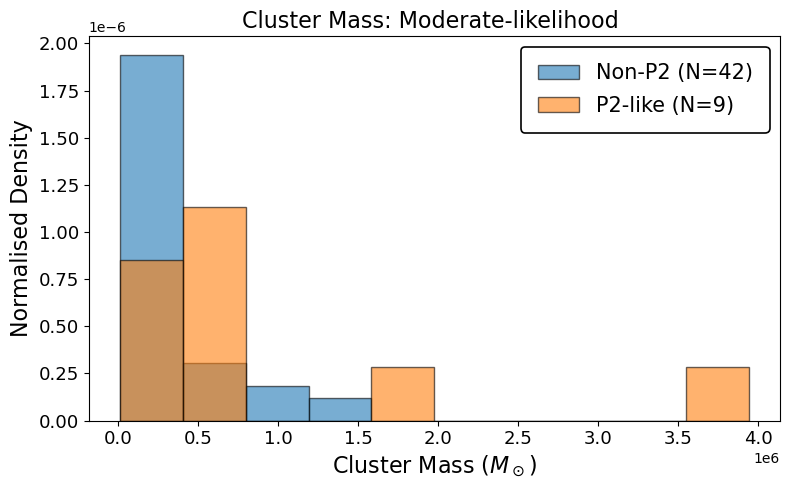

KS test: D = 0.5317, p = 0.01863 (significant)
MWU test: U = 301.0000, p = 0.005867 (significant)
P2 median = 5.18e+05, Non-P2 median = 1.95e+05
P2 mean = 9.73e+05, Non-P2 mean = 3.131e+05


,Bin,P2 clusters,Non-P2 clusters
0,"[1.34e+04, 4.06e+05]","NGC_1904, NGC_6341, NGC_6752","Djor_2, HP_1, NGC_1851, NGC_2298, NGC_288, NGC..."
1,"[4.06e+05, 7.99e+05]","NGC_2808, NGC_6205, NGC_6273, NGC_7078","FSR_1758, NGC_5024, NGC_5272, NGC_6656, NGC_7089"
2,"[7.99e+05, 1.19e+06]",,"Liller_1, NGC_104, Ter_5"
3,"[1.19e+06, 1.58e+06]",,"NGC_6388, NGC_6441"
4,"[1.58e+06, 1.98e+06]",NGC_6715,
5,"[1.98e+06, 2.37e+06]",,
6,"[2.37e+06, 2.76e+06]",,
7,"[2.76e+06, 3.15e+06]",,
8,"[3.15e+06, 3.55e+06]",,
9,"[3.55e+06, 3.94e+06]",NGC_5139,


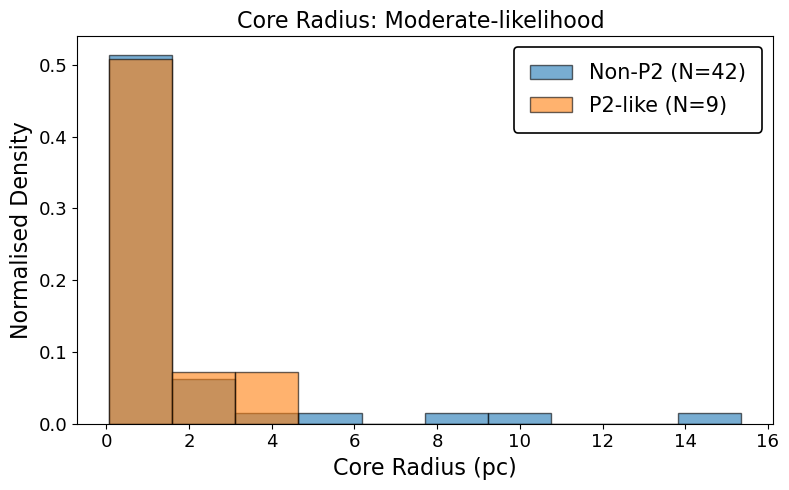

KS test: D = 0.2778, p = 0.532 (not significant)
MWU test: U = 154.5000, p = 0.4007 (not significant)
P2 median = 0.55, Non-P2 median = 0.81
P2 mean = 1.034, Non-P2 mean = 1.752


,Bin,P2 clusters,Non-P2 clusters
0,"[0.06, 1.59]","NGC_1904, NGC_2808, NGC_6273, NGC_6341, NGC_67...","Djor_2, HP_1, Liller_1, NGC_104, NGC_1851, NGC..."
1,"[1.59, 3.12]",NGC_6205,"NGC_3201, NGC_4590, NGC_5024, NGC_6809"
2,"[3.12, 4.65]",NGC_5139,NGC_288
3,"[4.65, 6.18]",,NGC_5466
4,"[6.18, 7.7]",,
5,"[7.7, 9.23]",,NGC_5053
6,"[9.23, 10.8]",,FSR_1758
7,"[10.8, 12.3]",,
8,"[12.3, 13.8]",,
9,"[13.8, 15.3]",,Pal_5


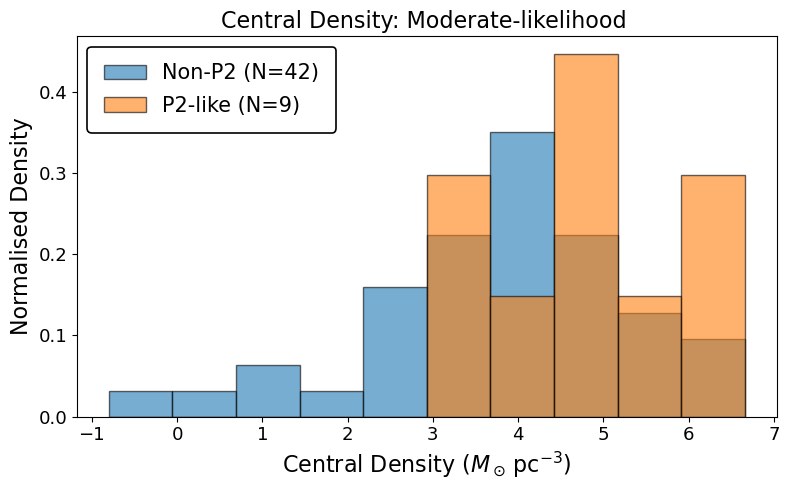

KS test: D = 0.3968, p = 0.1477 (not significant)
MWU test: U = 261.0000, p = 0.07727 (not significant)
P2 median = 4.56, Non-P2 median = 3.825
P2 mean = 4.774, Non-P2 mean = 3.745


,Bin,P2 clusters,Non-P2 clusters
0,"[-0.8, -0.054]",,Pal_5
1,"[-0.054, 0.692]",,NGC_5053
2,"[0.692, 1.44]",,"FSR_1758, NGC_5466"
3,"[1.44, 2.18]",,NGC_288
4,"[2.18, 2.93]",,"NGC_3201, NGC_4590, NGC_6809, NGC_6838, Ton_2"
5,"[2.93, 3.68]","NGC_5139, NGC_6205","Djor_2, HP_1, NGC_5024, NGC_5904, NGC_6218, NG..."
6,"[3.68, 4.42]",NGC_6273,"NGC_2298, NGC_5272, NGC_6121, NGC_6171, NGC_62..."
7,"[4.42, 5.17]","NGC_1904, NGC_2808, NGC_6752","NGC_104, NGC_362, NGC_6441, NGC_6522, NGC_7089..."
8,"[5.17, 5.91]",NGC_6715,"NGC_6388, NGC_6397, NGC_6544, NGC_6642"
9,"[5.91, 6.66]","NGC_6341, NGC_7078","Liller_1, NGC_1851, NGC_6293"


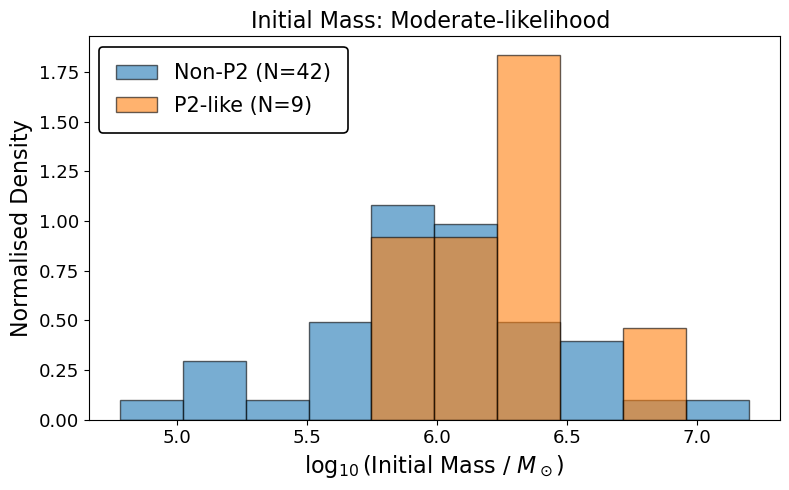

KS test: D = 0.4206, p = 0.1073 (not significant)
MWU test: U = 269.5000, p = 0.04806 (significant)
P2 median = 6.29, Non-P2 median = 5.98
P2 mean = 6.267, Non-P2 mean = 5.973


,Bin,P2 clusters,Non-P2 clusters
0,"[4.78, 5.02]",,Pal_5
1,"[5.02, 5.26]",,"NGC_5053, NGC_5466, NGC_6838"
2,"[5.26, 5.51]",,NGC_4590
3,"[5.51, 5.75]",,"NGC_288, NGC_3201, NGC_6218, NGC_6397, Ton_2"
4,"[5.75, 5.99]","NGC_6341, NGC_6752","NGC_2298, NGC_5272, NGC_5904, NGC_6171, NGC_62..."
5,"[5.99, 6.23]","NGC_6205, NGC_7078","Djor_2, FSR_1758, HP_1, NGC_1851, NGC_362, NGC..."
6,"[6.23, 6.47]","NGC_1904, NGC_2808, NGC_6273, NGC_6715","NGC_104, NGC_6293, NGC_6522, NGC_7089, Ter_9"
7,"[6.47, 6.72]",,"NGC_6380, NGC_6388, NGC_6441, NGC_6642"
8,"[6.72, 6.96]",NGC_5139,Ter_5
9,"[6.96, 7.2]",,Liller_1


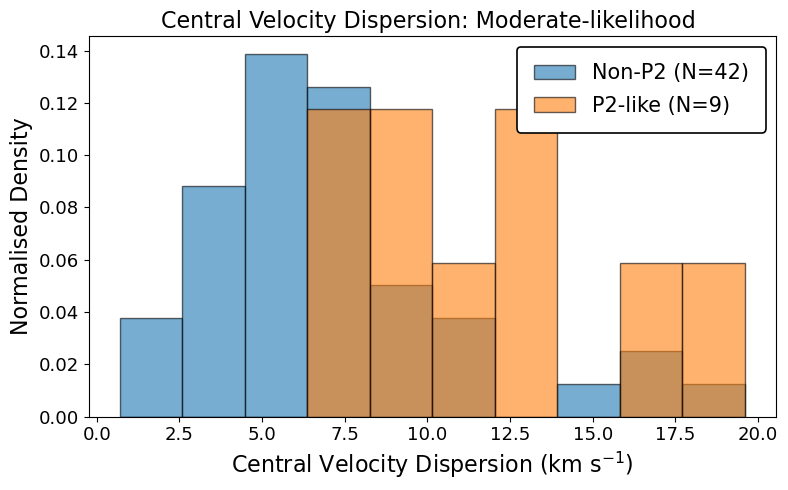

KS test: D = 0.5873, p = 0.006399 (significant)
MWU test: U = 313.0000, p = 0.002271 (significant)
P2 median = 11.6, Non-P2 median = 6.45
P2 mean = 11.79, Non-P2 mean = 7.1


,Bin,P2 clusters,Non-P2 clusters
0,"[0.7, 2.59]",,"NGC_5053, NGC_5466, Pal_5"
1,"[2.59, 4.48]",,"Djor_2, NGC_2298, NGC_288, NGC_4590, NGC_6171,..."
2,"[4.48, 6.37]",,"FSR_1758, HP_1, NGC_3201, NGC_6121, NGC_6218, ..."
3,"[6.37, 8.26]","NGC_1904, NGC_6752","NGC_5024, NGC_5272, NGC_5904, NGC_6229, NGC_62..."
4,"[8.26, 10.2]","NGC_6205, NGC_6341","NGC_362, NGC_6380, NGC_6553, NGC_6656"
5,"[10.2, 12]",NGC_6273,"NGC_104, NGC_1851, NGC_7089"
6,"[12, 13.9]","NGC_2808, NGC_7078",
7,"[13.9, 15.8]",,Ter_5
8,"[15.8, 17.7]",NGC_6715,"NGC_6388, NGC_6441"
9,"[17.7, 19.6]",NGC_5139,Liller_1


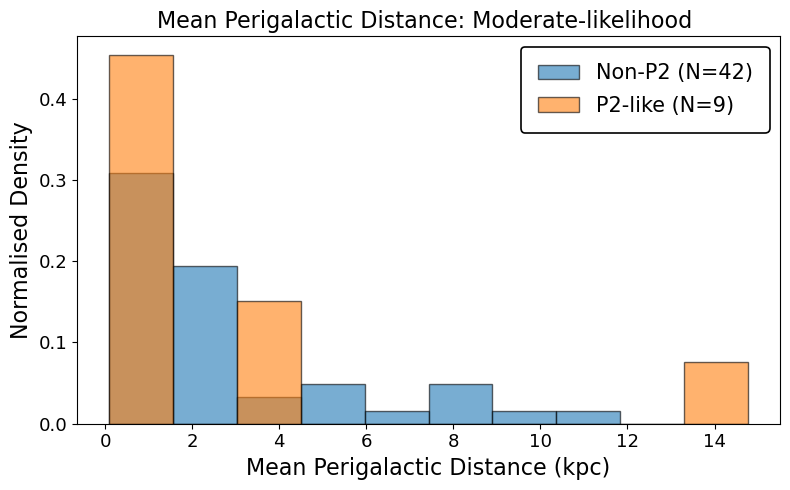

KS test: D = 0.2698, p = 0.5645 (not significant)
MWU test: U = 201.0000, p = 0.7763 (not significant)
P2 median = 1.47, Non-P2 median = 1.605
P2 mean = 3.209, Non-P2 mean = 2.671


,Bin,P2 clusters,Non-P2 clusters
0,"[0.09, 1.56]","NGC_1904, NGC_2808, NGC_5139, NGC_6205, NGC_62...","Djor_2, HP_1, Liller_1, NGC_1851, NGC_2298, NG..."
1,"[1.56, 3.03]",,"NGC_288, NGC_6218, NGC_6254, NGC_6304, NGC_639..."
2,"[3.03, 4.49]","NGC_6752, NGC_7078","FSR_1758, NGC_5904"
3,"[4.49, 5.96]",,"NGC_104, NGC_5272, NGC_6838"
4,"[5.96, 7.43]",,NGC_5466
5,"[7.43, 8.9]",,"NGC_3201, NGC_4590, Pal_5"
6,"[8.9, 10.4]",,NGC_5024
7,"[10.4, 11.8]",,NGC_5053
8,"[11.8, 13.3]",,
9,"[13.3, 14.8]",NGC_6715,


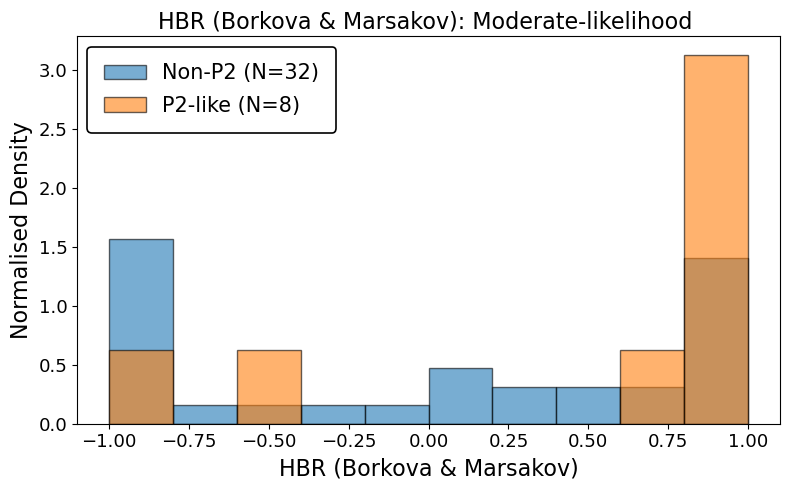

KS test: D = 0.4062, p = 0.2074 (not significant)
MWU test: U = 173.0000, p = 0.1312 (not significant)
P2 median = 0.88, Non-P2 median = 0.125
P2 mean = 0.4913, Non-P2 mean = 0.02456


,Bin,P2 clusters,Non-P2 clusters
0,"[-1, -0.8]",NGC_1904,"Liller_1, NGC_104, NGC_2298, NGC_362, NGC_6304..."
1,"[-0.8, -0.6]",,NGC_6171
2,"[-0.6, -0.4]",NGC_2808,Pal_5
3,"[-0.4, -0.2]",,NGC_1851
4,"[-0.2, 0]",,NGC_6121
5,"[0, 0.2]",,"NGC_3201, NGC_4590, NGC_5272"
6,"[0.2, 0.4]",,"NGC_5904, NGC_6229"
7,"[0.4, 0.6]",,"NGC_5053, NGC_5466"
8,"[0.6, 0.8]",NGC_7078,"NGC_5024, NGC_6522"
9,"[0.8, 1]","NGC_5139, NGC_6205, NGC_6341, NGC_6715, NGC_6752","NGC_288, NGC_6218, NGC_6254, NGC_6293, NGC_639..."


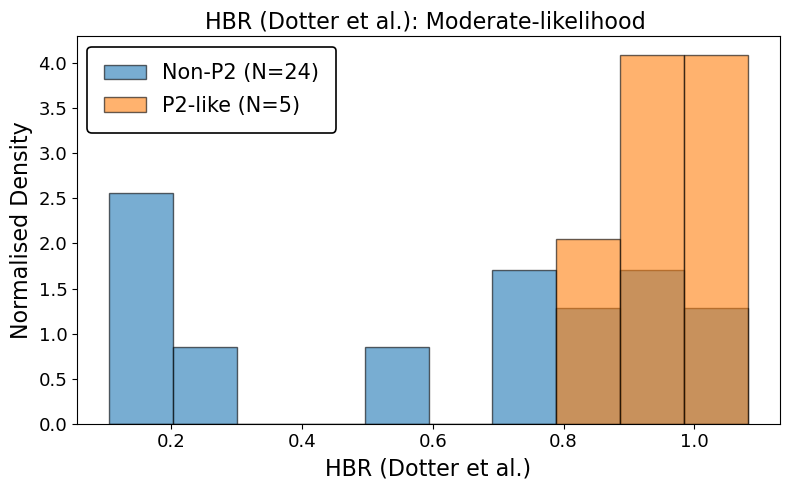

KS test: D = 0.7083, p = 0.01763 (significant)
MWU test: U = 104.0000, p = 0.01201 (significant)
P2 median = 0.966, Non-P2 median = 0.7285
P2 mean = 0.9762, Non-P2 mean = 0.6083


,Bin,P2 clusters,Non-P2 clusters
0,"[0.105, 0.203]",,"NGC_104, NGC_362, NGC_6304, NGC_6388, NGC_6441..."
1,"[0.203, 0.3]",,"NGC_1851, NGC_6171"
2,"[0.3, 0.398]",,
3,"[0.398, 0.496]",,
4,"[0.496, 0.594]",,"NGC_3201, NGC_6121"
5,"[0.594, 0.691]",,
6,"[0.691, 0.789]",,"NGC_4590, NGC_5053, NGC_5272, NGC_5466"
7,"[0.789, 0.887]",NGC_7078,"NGC_2298, NGC_5024, NGC_5904"
8,"[0.887, 0.984]","NGC_2808, NGC_6341","NGC_6397, NGC_6656, NGC_6809, NGC_7089"
9,"[0.984, 1.08]","NGC_6205, NGC_6752","NGC_288, NGC_6218, NGC_6254"


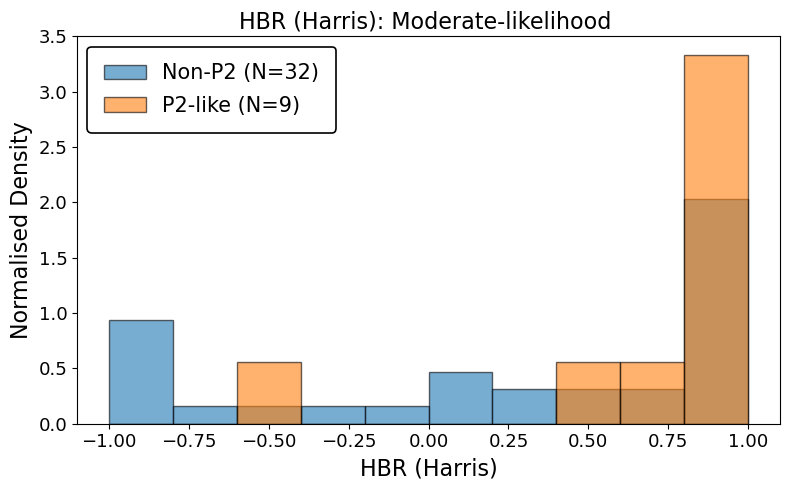

KS test: D = 0.3889, p = 0.1775 (not significant)
MWU test: U = 195.5000, p = 0.1079 (not significant)
P2 median = 0.9, Non-P2 median = 0.55
P2 mean = 0.7078, Non-P2 mean = 0.2591


,Bin,P2 clusters,Non-P2 clusters
0,"[-1, -0.8]",,"NGC_104, NGC_362, NGC_6304, NGC_6316, NGC_6388..."
1,"[-0.8, -0.6]",,NGC_6171
2,"[-0.6, -0.4]",NGC_2808,Pal_5
3,"[-0.4, -0.2]",,NGC_1851
4,"[-0.2, 0]",,NGC_6121
5,"[0, 0.2]",,"NGC_3201, NGC_4590, NGC_5272"
6,"[0.2, 0.4]",,"NGC_5904, NGC_6229"
7,"[0.4, 0.6]",NGC_6715,"NGC_5053, NGC_5466"
8,"[0.6, 0.8]",NGC_7078,"HP_1, NGC_6522"
9,"[0.8, 1]","NGC_1904, NGC_5139, NGC_6205, NGC_6273, NGC_63...","FSR_1758, NGC_2298, NGC_288, NGC_5024, NGC_621..."


In [73]:
run_all_histograms(df_p2, df_nonp2, parameters, bins=10, alpha=0.05)

In [74]:
stats_df = pd.DataFrame(stats_results)

output_csv = f"histogram_stats_{analysis_level}.csv"
stats_df.to_csv(output_csv, index=False)

print(f"Saved stats to {output_csv}")
display(stats_df)

Saved stats to histogram_stats_likely.csv


,Parameter,Analysis_level,N_P2,N_NonP2,KS_stat,KS_p,KS_significant,MWU_stat,MWU_p,MWU_significant,P2_median,NonP2_median
0,Mass,Moderate-Likelihood,9,42,0.531746,0.018631,True,301.0,0.005867,True,518000.000,195000.0000
1,rc,Moderate-Likelihood,9,42,0.277778,0.531957,False,154.5,0.400724,False,0.550,0.8100
2,rho_c,Moderate-Likelihood,9,42,0.396825,0.147717,False,261.0,0.077274,False,4.560,3.8250
3,lg(Mini),Moderate-Likelihood,9,42,0.420635,0.107302,False,269.5,0.048059,True,6.290,5.9800
4,sig0,Moderate-Likelihood,9,42,0.587302,0.006399,True,313.0,0.002271,True,11.600,6.4500
5,R_Per,Moderate-Likelihood,9,42,0.269841,0.564474,False,201.0,0.776284,False,1.470,1.6050
6,HBR_Borkova,Moderate-Likelihood,9,42,0.406250,0.207352,False,173.0,0.131230,False,0.880,0.1250
7,HBR_Dotter,Moderate-Likelihood,9,42,0.708333,0.017633,True,104.0,0.012012,True,0.966,0.7285
8,HBR_Harris,Moderate-Likelihood,9,32,0.388889,0.177489,False,195.5,0.107859,False,0.900,0.5500
